<a href="https://colab.research.google.com/github/aqmalio/Data-Science-2026/blob/main/Pertemuan5_Aqmal_250401020149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama: Aqmal
* Nim: 250401020149
* Kelas: IF405

## 1. Load & Inspect Dataset
Tahap awal adalah memuat library yang diperlukan dan menginspeksi dataset 'Tips'.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# Memuat dataset tips
df = sns.load_dataset('tips')

print(f"Ukuran dataset: {df.shape}")
print("\nTipe data kolom:")
print(df.dtypes)
print("\nStatistik deskriptif:")
display(df.describe().round(2))

Ukuran dataset: (244, 7)

Tipe data kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


## 2. Dashboard Visualisasi Data
Berikut adalah dashboard terpadu yang menampilkan empat jenis grafik utama untuk menganalisis perilaku pelanggan.

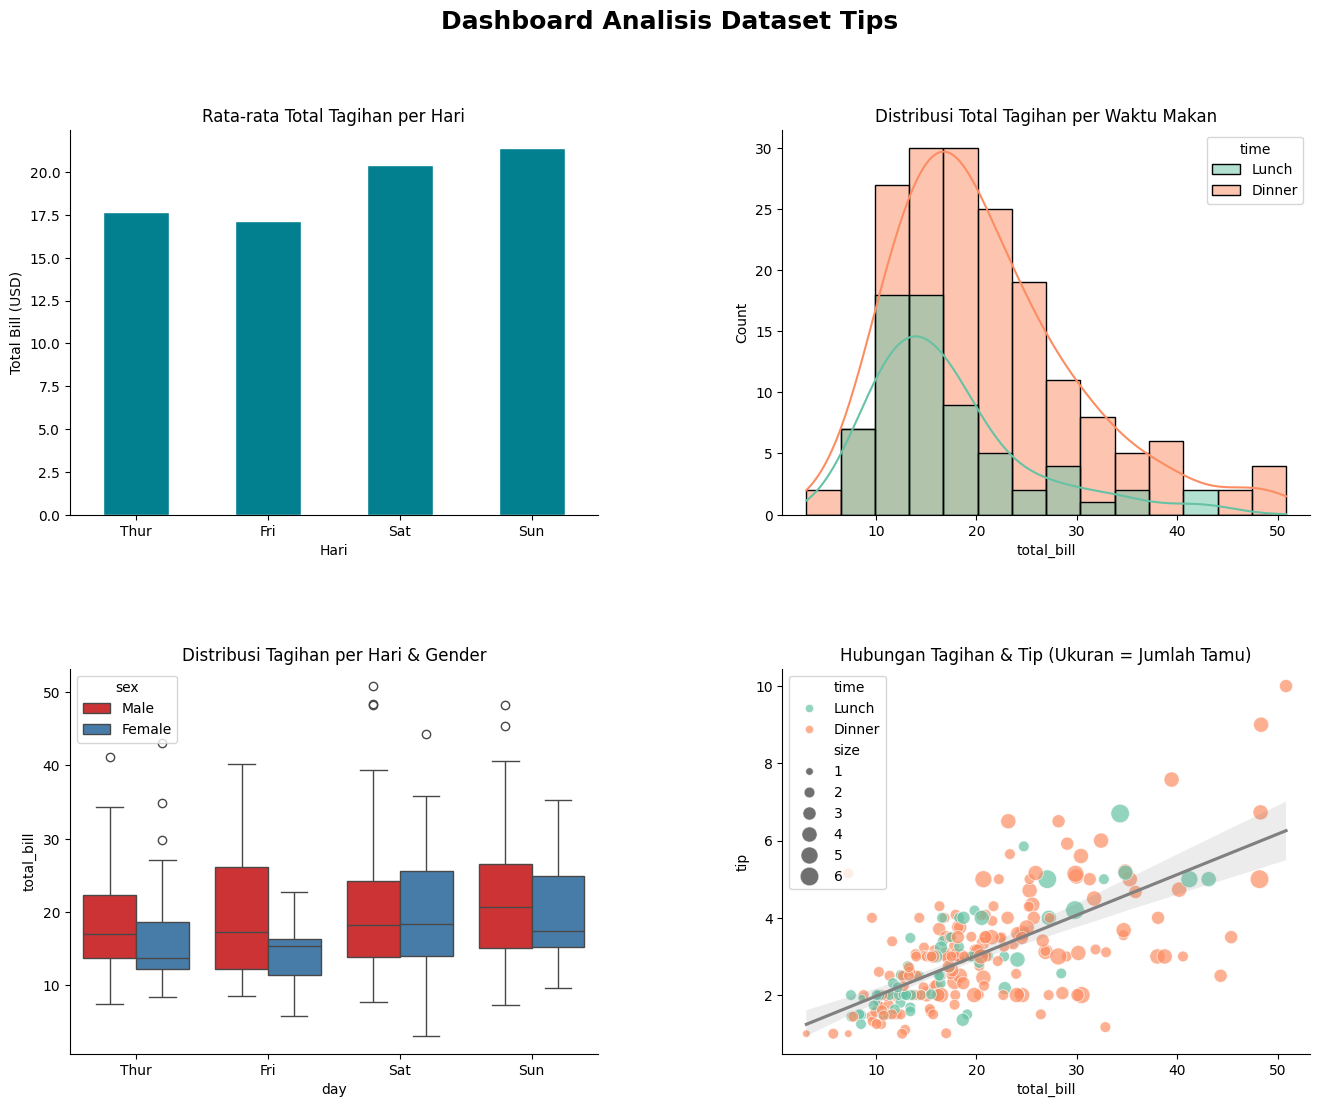

In [2]:
# SETUP FIGURE LAYOUT
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# GRAFIK 1: Bar Chart
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# GRAFIK 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(30,180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Grafik 1: Bar Chart
**What?**: Grafik menunjukkan rata-rata tagihan tertinggi terjadi pada hari Minggu (sekitar $21.41), sedangkan rata-rata terendah ada pada hari Jumat (\$17.15).
**So what?**: Hal ini menunjukkan bahwa pelanggan cenderung menghabiskan lebih banyak uang saat makan di akhir pekan dibandingkan hari kerja.
**Now what?**: Restoran dapat mempertimbangkan strategi staffing yang lebih banyak di hari Minggu untuk menangani volume transaksi yang lebih besar.

### Analisis Grafik 2: Histogram
**What?**: Distribusi tagihan saat makan malam (Dinner) lebih luas dan memiliki puncak frekuensi yang lebih tinggi di kisaran $10-$20 dibandingkan waktu makan siang (Lunch).
**So what?**: Waktu makan malam merupakan kontributor utama pendapatan karena frekuensi kedatangan dan nilai tagihan yang lebih tinggi.
**Now what?**: Apakah menu makan malam memiliki harga yang lebih mahal atau apakah pelanggan cenderung memesan lebih banyak menu tambahan?

### Analisis Grafik 3: Boxplot
**What?**: Boxplot menunjukkan bahwa laki-laki cenderung memiliki rentang tagihan yang lebih besar (outlier hingga $50.81 pada hari Sabtu) dibanding perempuan.
**So what?**: Terdapat variasi pengeluaran yang lebih ekstrem pada pelanggan laki-laki, terutama di akhir pekan.
**Now what?**: Kita bisa melakukan analisis lebih lanjut apakah kelompok laki-laki tersebut datang dalam rombongan yang lebih besar.

### Analisis Grafik 4: Scatter Plot
**What?**: Terlihat korelasi positif yang kuat antara total tagihan dan jumlah tip, di mana tip terbesar ($10.00) diberikan pada tagihan yang tinggi.
**So what?**: Pelayan memiliki peluang mendapatkan tip lebih besar jika mereka berhasil melakukan upselling sehingga total tagihan meningkat.
**Now what?**: Perlu diteliti apakah persentase tip tetap konsisten (misalnya 15%) di semua rentang harga atau menurun pada tagihan yang sangat mahal.

# Kesimpulan

**Apa yang dipelajari:**
Pada Sesi ini memberikan pemahaman tentang teknik visualisasi data menggunakan `matplotlib` dan `seaborn`, serta bagaimana menyusun dashboard statis yang informatif menggunakan `gridspec`.

**Temuan Utama:**
1. Hari Minggu merupakan hari dengan rata-rata transaksi tertinggi ($21.41).
2. Waktu makan malam (Dinner) memberikan kontribusi pendapatan yang lebih signifikan dibandingkan makan siang.
3. Terdapat korelasi positif yang kuat antara total tagihan dengan jumlah tip yang diberikan oleh pelanggan.

**Keterbatasan & Pertanyaan:**
Analisis ini terbatas pada satu dataset 'tips'. Pertanyaan eksploratif selanjutnya adalah apakah faktor cuaca atau lokasi restoran juga mempengaruhi besaran tip dan total tagihan secara signifikan?